# Induction Head Test

In [3]:
# Cell 0: Imports
import sys
import torch
from pathlib import Path

# Colab: files are in /content/
# Local: notebook is in notebooks/, project root is one level up
if Path('/content/data').exists():
    PROJECT_ROOT = Path('/content')
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))

from transformer_lens import HookedTransformer
import transformer_lens.utils as utils

print(f"Project root: {PROJECT_ROOT}")
from src.models import load_model, unload

Project root: /Users/trishasalas/Repos/Research/tmlr


### Load Model

In [6]:
model_name = "pythia-2.8b"
model, info = load_model(model_name)

Loaded pretrained model pythia-2.8b into HookedTransformer
Loaded pythia-2.8b on mps
  32 layers | 32 heads | d_model=2560 | d_mlp=10240 | parallel attn+MLP


### Baseline Prompt

In [7]:
prompt = "the cat sat the cat"
tokens = model.to_str_tokens(prompt)
logits, cache = model.run_with_cache(prompt)

# Check if L1H12 attends from second "cat" back to "sat"
attn = cache["pattern", 1][0, 12]
print(attn)

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [9.9740e-01, 2.6016e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.4055e-01, 6.0256e-01, 1.5689e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.8210e-07, 3.7164e-03, 9.9474e-01, 1.5450e-03, 0.0000e+00, 0.0000e+00],
        [9.8300e-07, 3.7697e-05, 1.0406e-01, 8.5831e-01, 3.7595e-02, 0.0000e+00],
        [2.9446e-07, 2.9754e-08, 3.3050e-04, 3.4158e-01, 5.6453e-01, 9.3562e-02]],
       device='mps:0')


### Declarative Prompts

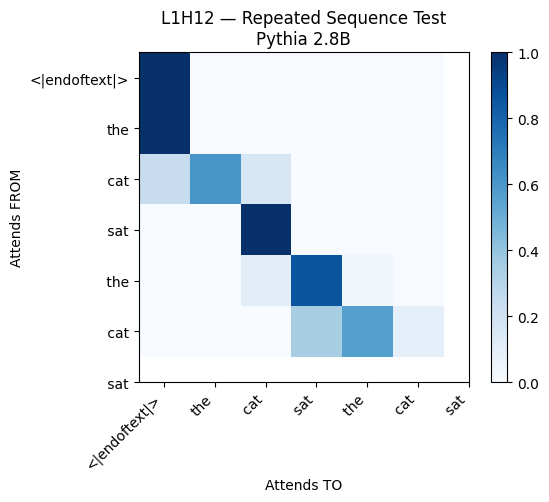

In [9]:
import matplotlib.pyplot as plt
import torch

# Your tensor
attn = cache["pattern", 1][0, 12]

prompt = "the cat sat the cat sat"
tokens = model.to_str_tokens(prompt)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn.cpu().numpy(), cmap="Blues")

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)
ax.set_title("L1H12 — Repeated Sequence Test\nPythia 2.8B", fontsize=12)
ax.set_xlabel("Attends TO")
ax.set_ylabel("Attends FROM")

plt.colorbar(im)
plt.tight_layout()
plt.savefig("../figures/L1H12-induction-test.png", dpi=150)
plt.show()

In [11]:
unload(model)

Model unloaded, memory cleared
